Logistic Regression Implementation

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [51]:
df= pd.read_csv(r"C:\Users\ACER\OneDrive\Desktop\ML project\Implementation\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [52]:
print(df.shape)
print(df.columns)
df.head()

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [54]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [55]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [56]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [57]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

In [58]:
df["Fare"] = df["Fare"].fillna(
    df["Fare"].median()
)

In [60]:
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [61]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [62]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [63]:
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int
)

In [64]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1


In [65]:
df.dtypes

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q      int64
Embarked_S      int64
dtype: object

In [66]:
y = df["Survived"]

In [67]:
X = df.drop(columns=["Survived"])

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 8)
y shape: (891,)


In [69]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,0,1
1,1,1,38.0,1,0,71.2833,0,0
2,3,1,26.0,0,0,7.9250,0,1
3,1,1,35.0,1,0,53.1000,0,1
4,3,0,35.0,0,0,8.0500,0,1


In [70]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size =0.2,
    random_state=42,
    stratify=y
)

In [71]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)


In [72]:
from sklearn.linear_model import LogisticRegression


In [73]:
model=LogisticRegression(max_iter=1000)

In [74]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [75]:
y_pred=model.predict(X_test)
print(y_pred)

[0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 1 0 1 1
 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0
 1 1 0 0 1 1 0 1 0 0 0 1 1 1 1 1 1 1 0 0 1 1 0 0 1 0 1 0 0 1 0]


In [76]:
y_prob = model.predict_proba(X_test)

print(y_prob[:5])

[[0.93000377 0.06999623]
 [0.95066692 0.04933308]
 [0.84256781 0.15743219]
 [0.96318473 0.03681527]
 [0.33073474 0.66926526]]


In [77]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8044692737430168


In [78]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[98 12]
 [23 46]]


In [79]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.7931034482758621
Recall: 0.6666666666666666
F1 Score: 0.7244094488188977


KNN implementation

In [80]:
print(X.shape)
print(y.shape)

(891, 8)
(891,)


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712, 8)
X_test: (179, 8)
y_train: (712,)
y_test: (179,)


In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
print(X_train_scaled[:5])

[[ 0.82956755 -0.74242727 -0.11207776 -0.46508428 -0.46618317  0.5138115
  -0.28933346  0.61197825]
 [-0.37094484 -0.74242727 -0.11207776 -0.46508428 -0.46618317 -0.66256323
  -0.28933346  0.61197825]
 [-1.57145722 -0.74242727 -0.11207776 -0.46508428 -0.46618317  3.95539858
  -0.28933346  0.61197825]
 [ 0.82956755  1.34693328 -0.87980748 -0.46508428  0.72778236 -0.46787435
  -0.28933346  0.61197825]
 [-0.37094484  1.34693328  0.11824116  0.47833454  0.72778236 -0.11597681
  -0.28933346  0.61197825]]


Naive Bayes Implementation

In [84]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)

In [85]:
model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [86]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

[0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1
 0 0 1 0 1 0 1 1 0 0 0 1 1 1 0 1 0 1 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 1 0 0 0
 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0]


In [87]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8156424581005587


In [88]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [89]:
y_pred_nb = model.predict(X_test_scaled)

print(y_pred_nb)

[0 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0
 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1
 1 0 0 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 1 1 0 0 1 1
 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1
 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 0 1 1 1]


In [90]:
from sklearn.metrics import accuracy_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.6089385474860335


In [91]:
from sklearn.metrics import confusion_matrix

cm_nb = confusion_matrix(y_test, y_pred_nb)

print(cm_nb)

[[45 65]
 [ 5 64]]


In [92]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1 Score:", f1_nb)

Precision: 0.49612403100775193
Recall: 0.927536231884058
F1 Score: 0.6464646464646465


Decision Tree

In [93]:
from sklearn.tree import DecisionTreeClassifier

In [94]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

In [95]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [96]:
y_pred_dt = dt_model.predict(X_test)

In [97]:
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.8212290502793296


In [98]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[96 14]
 [18 51]]


In [99]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1 Score:", f1_dt)

Precision: 0.7846153846153846
Recall: 0.7391304347826086
F1 Score: 0.7611940298507462


In [100]:
print("Tree Depth:", dt_model.get_depth())
print("Number of Leaves:", dt_model.get_n_leaves())

Tree Depth: 23
Number of Leaves: 155


In [101]:
dt_model_5 = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

dt_model_5.fit(X_train, y_train)

y_pred_dt_5 = dt_model_5.predict(X_test)

accuracy_dt_5 = accuracy_score(y_test, y_pred_dt_5)

print("Decision Tree Accuracy:", accuracy_dt_5)

Decision Tree Accuracy: 0.776536312849162


In [102]:
print("Tree Depth:", dt_model_5.get_depth())
print("Number of Leaves:", dt_model_5.get_n_leaves())

Tree Depth: 5
Number of Leaves: 23


In [103]:
depths = [3, 5, 7, 10, 15]

for depth in depths:
    model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    print(f"Depth {depth}: Accuracy = {acc:.4f}")

Depth 3: Accuracy = 0.7933
Depth 5: Accuracy = 0.7765
Depth 7: Accuracy = 0.8101
Depth 10: Accuracy = 0.7989
Depth 15: Accuracy = 0.8324


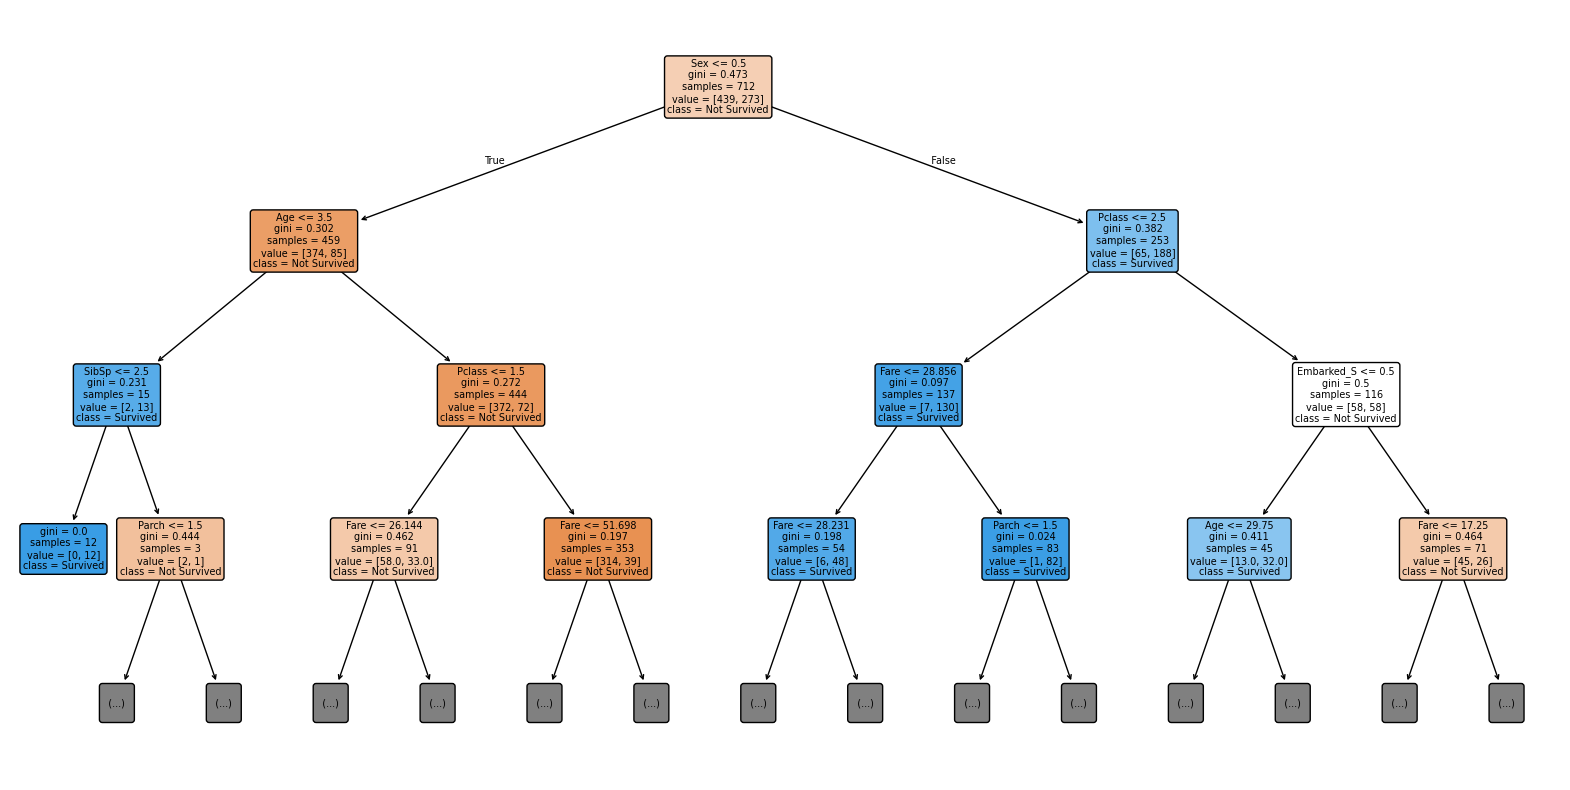

In [104]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    dt_model_5,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.show()

Support Vector Machine (SVM)

In [105]:
from sklearn.svm import SVC

In [128]:
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

In [129]:
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [130]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [131]:
from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8100558659217877


In [132]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[102   8]
 [ 26  43]]


In [133]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)

Precision: 0.8431372549019608
Recall: 0.6231884057971014
F1 Score: 0.7166666666666667


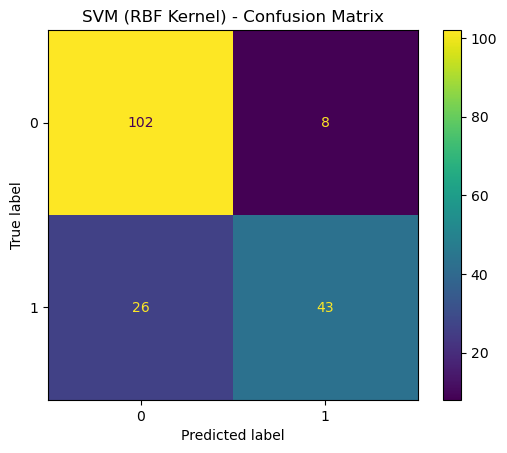

In [134]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.title("SVM (RBF Kernel) - Confusion Matrix")
plt.show()